In [79]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.linear_model import LinearRegression

from sklearn.model_selection import cross_validate
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import learning_curve
from sklearn.model_selection import ShuffleSplit
from sklearn.model_selection import train_test_split

from sklearn.metrics import mean_squared_error

from sklearn.pipeline import Pipeline

from sklearn.preprocessing import StandardScaler

In [80]:
np.random.seed(302)
plt.style.use('seaborn-v0_8')

##### We will use ShuffleSplit cross validation with:

* 10 folds (n_splits) and
* set aside 20% examples as test examples (test_size).

In [81]:
shuffle_split_cv = ShuffleSplit(n_splits=10 , test_size=0.2 , random_state=0)

In [82]:
features , label = fetch_california_housing(as_frame=True , return_X_y=True)

feature_train , feature_test , label_train , label_test = train_test_split(features , label , random_state=42)

In [83]:
assert (feature_train.shape[0] == label_train.shape[0])
assert (feature_test.shape[0] == label_test.shape[0])

In [84]:
lin_reg_pipeline = Pipeline([
    ("std_scaler" , StandardScaler()),
    ("regressor" , LinearRegression())
])

lin_reg_pipeline.fit(feature_train , label_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('std_scaler', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None


In [85]:
print("intercept (W_0) ->",lin_reg_pipeline[-1].intercept_.round(2))
print("Weights (W_1 , W_2 , ... , W_m) ->", lin_reg_pipeline[-1].coef_)

intercept (W_0) -> 2.07
Weights (W_1 , W_2 , ... , W_m) -> [ 0.85210815  0.12065533 -0.30210555  0.34860575 -0.00164465 -0.04116356
 -0.89314697 -0.86784046]


In [86]:
# Model Evaluation

test_error = lin_reg_pipeline.score(feature_test , label_test)
print("Test Error is" , test_error)

train_error = lin_reg_pipeline.score(feature_train , label_train)
print("Train Error is",train_error)

Test Error is 0.591050979549135
Train Error is 0.609873031052925


In [87]:
# Cross validation

lin_reg_score = cross_val_score(
    lin_reg_pipeline,
    feature_train,
    label_train,
    scoring = "neg_mean_squared_error",
    cv = shuffle_split_cv
)

print(-(lin_reg_score))
print(f"Mean: {-(lin_reg_score.mean()):.3f} , Std: {-(lin_reg_score.std()):.3f}")

[0.50009976 0.52183352 0.55931218 0.52110499 0.56059203 0.50510767
 0.52386194 0.54775518 0.5007161  0.54713448]
Mean: 0.529 , Std: -0.022


In [93]:
lin_reg_cv_result = cross_validate(
    lin_reg_pipeline,
    feature_train,
    label_train,
    scoring="neg_mean_squared_error",
    return_train_score = True,
    return_estimator = True
)

lin_reg_cv_result

{'fit_time': array([0.00399947, 0.00399089, 0.00399923, 0.0040009 , 0.00400162]),
 'score_time': array([0.00100017, 0.        , 0.00100064, 0.0009973 , 0.00099945]),
 'estimator': [Pipeline(steps=[('std_scaler', StandardScaler()),
                  ('regressor', LinearRegression())]),
  Pipeline(steps=[('std_scaler', StandardScaler()),
                  ('regressor', LinearRegression())]),
  Pipeline(steps=[('std_scaler', StandardScaler()),
                  ('regressor', LinearRegression())]),
  Pipeline(steps=[('std_scaler', StandardScaler()),
                  ('regressor', LinearRegression())]),
  Pipeline(steps=[('std_scaler', StandardScaler()),
                  ('regressor', LinearRegression())])],
 'test_score': array([-0.54459143, -0.48253877, -0.53937116, -0.5100916 , -0.54460418]),
 'train_score': array([-0.51459246, -0.53028102, -0.51775751, -0.52418832, -0.51466119])}

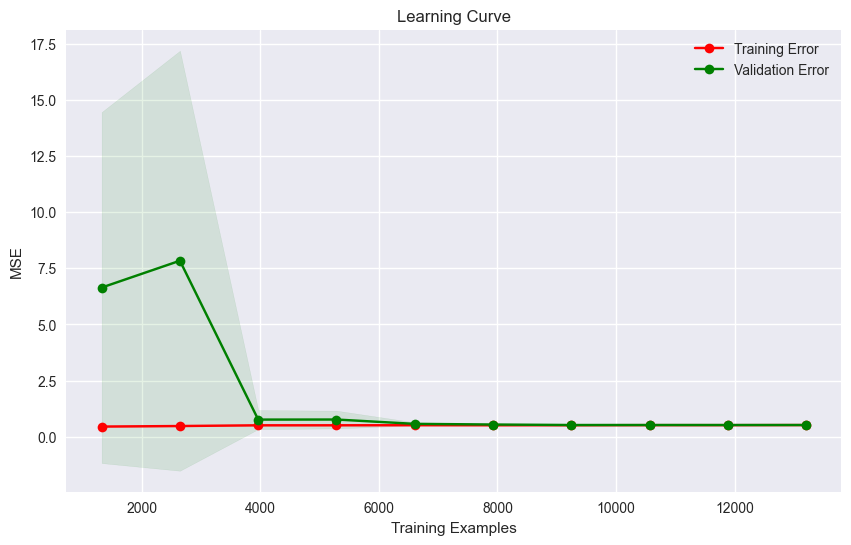

In [89]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.model_selection import learning_curve
from sklearn.linear_model import LinearRegression

# Dataset

x, y = fetch_california_housing(as_frame=True, return_X_y=True)

x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42
)

# Model

model = LinearRegression()

# Learning Curve Data

train_sizes, train_scores, test_scores, fit_times, _ = learning_curve(
    estimator=model,
    X=x_train,
    y=y_train,
    cv=5,
    scoring="neg_mean_squared_error",
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1,
    return_times=True
)

# Convert negative MSE to positive MSE

train_scores = -train_scores
test_scores = -test_scores

# Mean and Standard Deviation

train_scores_mean = np.mean(train_scores, axis=1)
train_scores_std = np.std(train_scores, axis=1)

test_scores_mean = np.mean(test_scores, axis=1)
test_scores_std = np.std(test_scores, axis=1)

# Plot Style

plt.style.use("seaborn-v0_8-darkgrid")

# Plot

plt.figure(figsize=(10,6))

# Training Error Region

plt.fill_between(
    train_sizes,
    train_scores_mean - train_scores_std,
    train_scores_mean + train_scores_std,
    alpha=0.1,
    color="red"
)

# Test Error Region

plt.fill_between(
    train_sizes,
    test_scores_mean - test_scores_std,
    test_scores_mean + test_scores_std,
    alpha=0.1,
    color="green"
)

# Training Curve

plt.plot(
    train_sizes,
    train_scores_mean,
    "o-",
    color="red",
    label="Training Error"
)

# Test Curve

plt.plot(
    train_sizes,
    test_scores_mean,
    "o-",
    color="green",
    label="Validation Error"
)

# Labels

plt.xlabel("Training Examples")
plt.ylabel("MSE")

plt.title("Learning Curve")

plt.legend(loc="best")

plt.show()

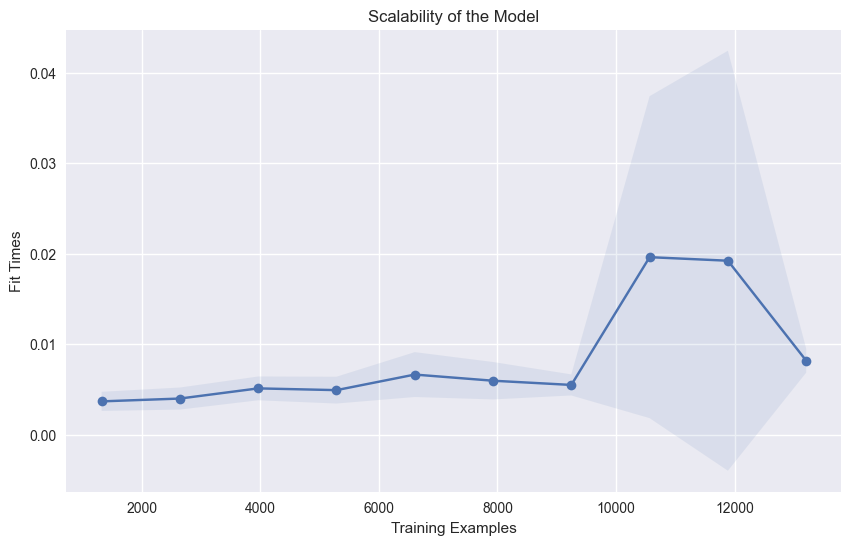

In [90]:
def plot_scalability_curve(train_sizes, fit_times):

    fit_times_mean = np.mean(fit_times, axis=1)
    fit_times_std = np.std(fit_times, axis=1)

    plt.figure(figsize=(10,6))

    plt.fill_between(
        train_sizes,
        fit_times_mean - fit_times_std,
        fit_times_mean + fit_times_std,
        alpha=0.1
    )

    plt.plot(
        train_sizes,
        fit_times_mean,
        "o-"
    )

    plt.xlabel("Training Examples")
    plt.ylabel("Fit Times")
    plt.title("Scalability of the Model")

    plt.show()

plot_scalability_curve(train_sizes, fit_times)

In [91]:
# Model Examination
features_names = feature_train.columns
features_names

Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude'],
      dtype='str')

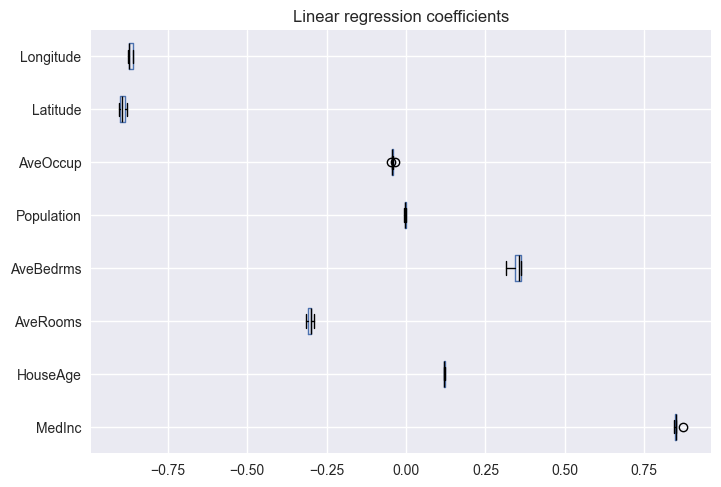

In [95]:
coefs = [est[-1].coef_ for est in lin_reg_cv_result["estimator"] ]
weights_df = pd.DataFrame(coefs, columns=features_names)

color = {"whiskers": "black", "medians": "black", "caps": "black"}
weights_df.plot.box(color=color, vert=False) #, figsize=(6, 16))
_= plt.title("Linear regression coefficients")